<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%203/week3_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — Exploring the Titanic Dataset

**Goal:** Apply probability to real, messy data. Before building any model, we explore who survived the 1912 Titanic sinking and why — computing real conditional probabilities straight from the data.

**The connection to theory:** a survival rate like *P(survived | female)* is exactly a **conditional probability**. We'll compute it two independent ways — directly by counting, and via **Bayes' theorem** — and confirm they agree. Later this week, logistic regression will learn these same patterns automatically.

---

## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

%matplotlib inline

---
## 1. Load the Data

The Titanic dataset has 891 passengers (rows) and 15 columns describing each one: whether they survived, their sex, age, passenger class, fare paid, and more.

In [2]:
df = sns.load_dataset("titanic")

print(f"Rows in dataset: {df.shape[0]}")
print(f"Columns in dataset: {df.shape[1]}")

Rows in dataset: 891
Columns in dataset: 15


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## 2. Inspect the Data

`df.info()` shows column types and missing values; `df.describe()` summarizes the numeric columns. Two things to look for before modeling:
- **Missing values** — `age` has gaps (714 non-null out of 891), and `deck` is mostly empty. These must be handled before training.
- **Numeric vs categorical** — `age` and `fare` are numeric; `sex`, `class`, and `embarked` are categorical and will need encoding into numbers.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Group counts

How many passengers fall into each sex and class? (Counts only — survival rates come next.)

In [6]:
sex_groupby = df.groupby('sex', observed=True)['survived'].count()
class_groupby = df.groupby('class', observed=True)['survived'].count()

In [7]:
sex_groupby

,survived
sex,
female,314
male,577


In [8]:
class_groupby

,survived
class,
First,216
Second,184
Third,491


---
## 3. Survival Rates — Conditional Probability in Action

A survival rate for a group is the conditional probability of survival *given* membership in that group:

$$P(\text{survived} \mid \text{group}) = \frac{\text{survivors in group}}{\text{total in group}}$$

`groupby(...).mean()` computes this directly — since `survived` is coded as 0/1, its mean *is* the survival rate.

In [9]:
print("Survival rate by sex:")
print(df.groupby('sex', observed=True)['survived'].mean())
print("\nSurvival rate by class:")
print(df.groupby('class', observed=True)['survived'].mean())

Survival rate by sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


These rates reveal the dominant pattern: **women survived at ~74%, men at ~19%**, and **first-class passengers far more than third-class**. "Women and children first" and class privilege, visible directly in the numbers.

### Cross-tabulation
A crosstab shows the raw counts behind those rates — survivors vs non-survivors, split by sex.

In [10]:
pd.crosstab(df['sex'], df['survived'])

survived,0,1
sex,,
female,81,233
male,468,109


---
## 4. P(Survived | Female), Two Ways

We now compute the same conditional probability **two independent ways** and confirm they agree. If they match, we've verified both our understanding and Bayes' theorem.

### Way 1 — Direct count
$$P(\text{survived} \mid \text{female}) = \frac{\text{female survivors}}{\text{total females}} = \frac{233}{314} \approx 0.742$$

### Way 2 — Bayes' theorem
Bayes lets us *flip* a conditional probability around:

$$P(\text{survived} \mid \text{female}) = \frac{P(\text{female} \mid \text{survived}) \cdot P(\text{survived})}{P(\text{female})}$$

We'll compute each piece on the right, then combine them — and get the same 0.742.

**First, the base rates we need.**

In [11]:
# P(survived): fraction of all passengers who survived
num_lived = len(df[df['survived'] == 1])
num_dec = len(df[df['survived'] != 1])

print(f"# survived: {num_lived}")
print(f"# deceased: {num_dec}")
# Sanity check: they sum to the dataset size
print("Sum matches dataset:", np.allclose(num_lived + num_dec, df.shape[0]))

prob_survived = num_lived / df.shape[0]
print(f"P(survived) = {prob_survived:.4f}")

# survived: 342
# deceased: 549
Sum matches dataset: True
P(survived) = 0.3838


In [12]:
# P(female): fraction of all passengers who are female
num_female = len(df[df['sex'] == 'female'])
num_male = len(df[df['sex'] == 'male'])
print("Sum matches dataset:", np.allclose(num_female + num_male, df.shape[0]))

prob_female = num_female / df.shape[0]
print(f"P(female) = {prob_female:.4f}")

Sum matches dataset: True
P(female) = 0.3524


In [13]:
# P(female | survived): among survivors, the fraction who are female
num_female_survived = len(df[(df['sex'] == 'female') & (df['survived'] == 1)])
P_fem_given_surv = num_female_survived / num_lived
print(f"Female survivors: {num_female_survived}")
print(f"P(female | survived) = {P_fem_given_surv:.4f}")

Female survivors: 233
P(female | survived) = 0.6813


**Now apply Bayes' theorem.**

$$P(\text{survived} \mid \text{female}) = \frac{P(\text{female} \mid \text{survived}) \cdot P(\text{survived})}{P(\text{female})}$$

The key is getting the formula right: **P(survived)** goes in the numerator (alongside the flipped conditional), and **P(female)** goes in the denominator.

In [14]:
# Bayes: P(S|F) = P(F|S) * P(S) / P(F)
P_surv_given_fem = (P_fem_given_surv * prob_survived) / prob_female
print(f"Bayes  P(survived | female) = {P_surv_given_fem:.4f}")

# Way 1 for comparison: direct count
direct = num_female_survived / num_female
print(f"Direct P(survived | female) = {direct:.4f}")

print("\nBoth methods agree:", np.allclose(P_surv_given_fem, direct))

Bayes  P(survived | female) = 0.7420
Direct P(survived | female) = 0.7420

Both methods agree: True


Both give **0.742**. The direct count and Bayes' theorem agree exactly — which is the whole point: Bayes is just a consistent way to re-express conditional probabilities, and seeing it land on the same number the direct count gives is the proof it works.

---

## 5. Visualize Survival Rates

The patterns below are exactly what a model will learn to capture.

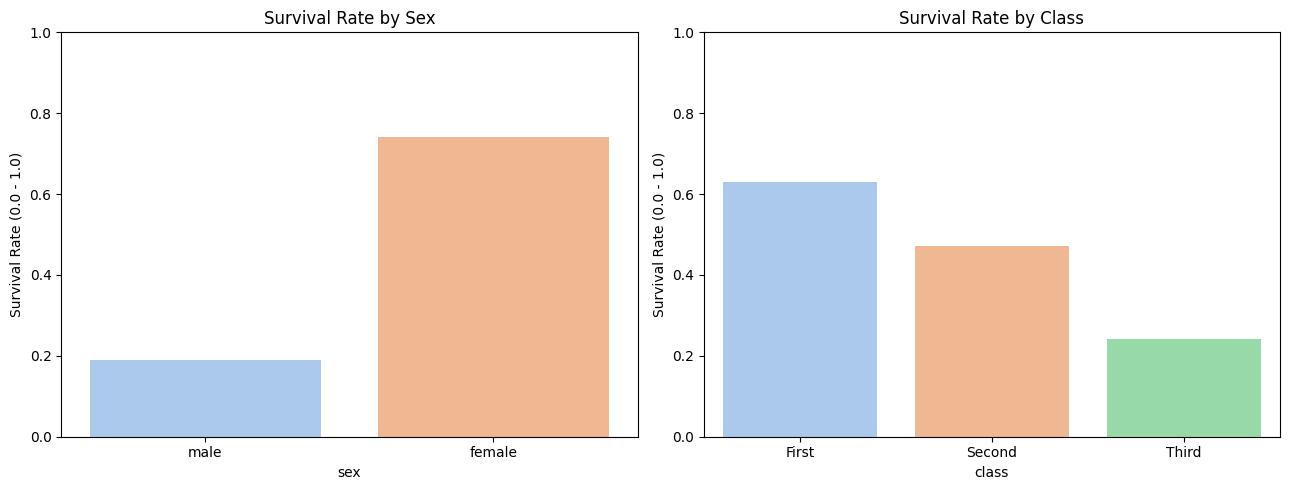

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df, x='sex', y='survived', palette='pastel',
            hue='sex', errorbar=None, ax=ax1)
ax1.set_title("Survival Rate by Sex")
ax1.set_ylabel("Survival Rate (0.0 - 1.0)")
ax1.set_ylim(0, 1)

sns.barplot(data=df, x='class', y='survived', palette='pastel',
            hue='class', errorbar=None, ax=ax2)
ax2.set_title("Survival Rate by Class")
ax2.set_ylabel("Survival Rate (0.0 - 1.0)")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 6. Hypothesis — Which Features Predict Survival?

Based on the survival rates computed above, before building any model:

**Most predictive features appear to be `sex` and `class`.**

- **Sex** shows the largest gap: ~74% of women survived vs ~19% of men — a difference of over 50 percentage points.
- **Class** shows a clear gradient: first-class passengers survived at much higher rates than third-class, reflecting both cabin location and evacuation priority.

Other features like `age` (children prioritized) and `fare` (correlated with class) likely add smaller amounts of predictive signal. When we train logistic regression later this week, we'll check whether the model agrees by inspecting which features get the largest weights.

---

## Summary

| Step | What we did |
|---|---|
| Load + inspect | 891 passengers, 15 columns; found missing values in `age`, `deck` |
| Survival rates | P(survived\|female) ≈ 0.74, P(survived\|male) ≈ 0.19 |
| Bayes check | Confirmed P(survived\|female) = 0.742 two independent ways |
| Hypothesis | `sex` and `class` look most predictive |

**Next: handle missing values and encode categorical features, then implement logistic regression from scratch to learn these patterns automatically.**